In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, lower, trim, regexp_replace, monotonically_increasing_id, row_number, lit
from pyspark.sql.window import Window

postgres_jar = "/home/espinozaje/jars/postgresql-42.7.3.jar"

# 1. SPARK POTENTE (VM1)

spark = SparkSession.builder \
    .appName("Nodo_IA_VM1") \
    .config("spark.driver.memory", "6g") \
    .config("spark.master", "local[2]") \
    .config("spark.jars", postgres_jar) \
    .config("spark.driver.extraClassPath", postgres_jar) \
    .getOrCreate()


print(f"✅ Nodo IA (VM1) iniciado.")

# 2. LEER DE MI PROPIA BASE DE DATOS (Localhost)

print("📥 Recogiendo datos de la tabla puente...")

db_url = "jdbc:postgresql://localhost:5432/data_clinica"

df_pre = spark.read \
    .format("jdbc") \
    .option("url", db_url) \
    .option("dbtable", "pacientes_buffer") \
    .option("user", "postgres") \
    .option("password", "admin") \
    .load()


# 3. GENERAR IDs

print("🔢 Generando IDs para procesamiento...")

w = Window.orderBy(lit("A"))

df_pacientes_con_id = df_pre.withColumn("id_unico", row_number().over(w))

df_pacientes_con_id.cache()

print(f"✅ Datos listos para IA: {df_pacientes_con_id.count()} registros.")

# 4. CARGAR DICCIONARIO CIE-10 (Local)

df_diccionario = spark.read.option("encoding", "ISO-8859-1").csv("CIE10_2021.csv", header=True, inferSchema=True) \
    .dropna(subset=['DESCRIPCION', 'CODIGO']) \
    .withColumn("texto_limpio", lower(trim(col("DESCRIPCION"))))

print("✅ Diccionario cargado.") 

25/11/24 16:41:16 WARN Utils: Your hostname, Debian resolves to a loopback address: 127.0.1.1; using 10.0.2.15 instead (on interface enp0s3)
25/11/24 16:41:16 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
25/11/24 16:41:17 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


✅ Nodo IA (VM1) iniciado.
📥 Recogiendo datos de la tabla puente...
🔢 Generando IDs para procesamiento...


25/11/24 16:41:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/24 16:41:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/24 16:41:27 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/24 16:41:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/24 16:41:28 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/24 16:41:34 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/24 1

✅ Datos listos para IA: 131981 registros.
✅ Diccionario cargado.


In [27]:
import nltk
from nltk.stem import SnowballStemmer
from pyspark.ml.feature import Tokenizer, StopWordsRemover, Word2Vec
from pyspark.sql.types import StringType, ArrayType, IntegerType
from pyspark.sql.functions import udf, col, size, regexp_replace, lower, trim



# 1. NLTK
try: nltk.data.find('tokenizers/punkt')
except LookupError: nltk.download('punkt')

stemmer = SnowballStemmer("spanish")

@udf(ArrayType(StringType()))
def stem_tokens(tokens):
    if not tokens: return []
    return [stemmer.stem(token) for token in tokens]

@udf(IntegerType())
def count_non_zeros(v):
    if v is None: return 0
    return v.numNonzeros()

# 2. Tokenizer
tokenizer = Tokenizer(inputCol="texto_limpio", outputCol="tokens_raw")
# 3. Stopwords (Un poco más agresivas para limpiar ruido)

lista_stopwords = [
    "de", "la", "el", "en", "y", "o", "un", "una", "con", "del", "los", "las", "al", "su", "que",
    "lo", "por", "para", "es", "son", "se", "mi", "mis", "sus", "tu"
]

stopwords_remover = StopWordsRemover(
    inputCol="tokens_raw",
    outputCol="tokens_filtrados",
    stopWords=lista_stopwords
)

# 4. WORD2VEC (ALTA PRECISIÓN)
# vectorSize 100: Separa mejor los significados.
# maxIter 20: Aprende mejor las relaciones.

word2Vec = Word2Vec(
    vectorSize=100,    # <--- SUBIMOS CALIDAD (Antes 50)
    minCount=2,        # Ignora palabras que aparecen una sola vez (suelen ser typos/ruido)
    inputCol="tokens_filtrados",
    outputCol="features",
    stepSize=0.025,
    maxIter=20         # <--- MÁS ENTRENAMIENTO (Antes 10)
)

print("✅ Configuración de ALTA PRECISIÓN lista.") 

✅ Configuración de ALTA PRECISIÓN lista.


In [28]:
from pyspark.ml import Pipeline
from pyspark.sql.functions import broadcast

# 1. Limpieza
def limpiar_texto(df, col_name):
    # 1. Limpieza base
    df = df.withColumn("texto_limpio", lower(trim(col(col_name)))) \
           .filter(col("texto_limpio").isNotNull()) \
           .withColumn("texto_limpio", regexp_replace("texto_limpio", "[^a-z0-9áéíóúñ ]", ""))

    # 2. Correcciones Específicas
    df = df \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "sensibilidad a la luz", "alteraciones visuales subjetivas")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "molestia a la luz", "alteraciones visuales subjetivas")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "fotofobia", "alteraciones visuales subjetivas")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "visión borrosa", "alteraciones visuales subjetivas")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "vision borrosa", "alteraciones visuales subjetivas")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "ojos llorosos", "epífora")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "dificultad para respirar", "disnea")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "falta de aire", "disnea")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "ahogo", "disnea")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "sibilancias", "silbido")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "le silba el pecho", "silbido")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "opresión en el pecho", "dolor en el pecho")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "opresion en el pecho", "dolor en el pecho")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "estornudos", "estornudo")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "congestión nasal", "otros transtornos especificados de la nariz y los senos paranasales")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "congestion nasal", "otros transtornos especificados de la nariz y los senos paranasales")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "tos seca", "tos")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "acidez estomacal", "acidez")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "ardor de estomago", "acidez")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "dolor abdominal", "otros dolores abdominales y los no especificados")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "dolor de barriga", "otros dolores abdominales y los no especificados")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "náuseas", "náusea y vómito")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "nauseas", "náusea y vómito")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "vómitos", "náusea y vómito")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "vomitos", "náusea y vómito")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "dolor de cabeza", "cefalea")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "cansancio", "malestar y fatiga")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "fatiga", "malestar y fatiga")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "micción frecuente", "poliuria")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "miccion frecuente", "poliuria")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "sed excesiva", "polidipsia")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "pérdida de olfato", "anosmia")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "perdida de olfato", "anosmia")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "picazón", "prurito no especificado")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "picazon", "prurito no especificado")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "mareos", "mareo y desvanecimiento")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "^diabetes$", "diabetes mellitus no especificada")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "^hipertensión$", "hipertensión esencial primaria")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "^hipertension$", "hipertensión esencial primaria")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "^alergia$", "alergia no especificada")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "^asma$", "asma no especificada")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "presion alta", "hipertension esencial primaria")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "azucar alta", "diabetes mellitus no especificada")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "lagrimeo", "epífora")) \
        .withColumn("texto_limpio", regexp_replace("texto_limpio", "^gripe$", "influenza con otras manifestaciones respiratorias virus no identificado"))

    return df

df_dic_prep = limpiar_texto(df_diccionario, "DESCRIPCION")

df_pac_prep = limpiar_texto(df_pacientes_con_id, "síntomas")

df_corpus = df_dic_prep.select("texto_limpio").union(df_pac_prep.select("texto_limpio"))

pipeline = Pipeline(stages=[tokenizer, stopwords_remover, word2Vec])

model = pipeline.fit(df_corpus)

# 2. Vectorizar Diccionario
# LO CAMBIAMOS A PANDAS (RAM pura) porque el diccionario es pequeño (10k-20k filas)
# Esto permite buscar rapidísimo sin usar Spark LSH

print("⏳ Pasando diccionario a memoria rápida...")

df_dic_vec = model.transform(df_dic_prep).filter(size(col("tokens_filtrados")) > 0)

# Seleccionamos solo código y vector

pandas_dic = df_dic_vec.select("CODIGO", "DESCRIPCION", "features").toPandas()
print(f"✅ Diccionario listo en memoria RAM ({len(pandas_dic)} códigos).") 

⏳ Pasando diccionario a memoria rápida...


✅ Diccionario listo en memoria RAM (12674 códigos).


In [29]:
import numpy as np
import shutil
import gc
from pyspark.sql.functions import split, explode, collect_list, concat_ws, monotonically_increasing_id, col, when, struct, lit
from pyspark.sql.types import StructType, StructField, StringType
from pyspark.sql.functions import udf

# Limpieza salida
output_path = "resultado_final_parts"
try: shutil.rmtree(output_path)
except: pass

# 1. Preparamos la matriz del diccionario (NumPy)
# Normalizamos los vectores del diccionario UNA VEZ para acelerar el cálculo

print("Preparando matriz matemática...")
# Convertimos la lista de vectores Spark a una matriz NumPy
dic_matrix = np.array(pandas_dic['features'].tolist())

# Calculamos la norma (magnitud) de cada vector del diccionario para el cálculo del Coseno

dic_norms = np.linalg.norm(dic_matrix, axis=1)

# Evitamos división por cero poniendo un valor minúsculo donde sea 0
dic_norms[dic_norms == 0] = 1e-10
dic_codigos = pandas_dic['CODIGO'].values
dic_desc = pandas_dic['DESCRIPCION'].values

# 2. Función de búsqueda manual (Numpy Puro - Sin Scipy)

def buscar_mejor_match_manual(vector_paciente):
    if vector_paciente is None or len(vector_paciente) == 0:
        return None, None

    # Convertir a array
    v_paciente = np.array(vector_paciente)
    norm_paciente = np.linalg.norm(v_paciente)

    if norm_paciente == 0: return None, None

    # --- CÁLCULO DE COSENO MANUAL (Matemática Pura) ---
    # Fórmula: (A . B) / (|A| * |B|)
    # Esto hace lo mismo que cdist pero sin la librería que te falló
    # 1. Producto Punto (Numerador)
    dot_products = np.dot(dic_matrix, v_paciente)

    # 2. Similitud
    similarities = dot_products / (dic_norms * norm_paciente)

    # 3. Distancia = 1 - Similitud (Para que 0 sea igual y 1 sea diferente)
    dists = 1.0 - similarities
    # Encontrar el índice del mínimo (el más cercano)
    min_idx = np.argmin(dists)
    min_dist = dists[min_idx]
    # Umbral (0.6 sigue siendo bueno, si quieres ser MUY estricto usa 0.35)
    if min_dist > 0.35:
        return None, None

    return str(dic_codigos[min_idx]), str(dic_desc[min_idx])

# 3. Registrar UDF

schema_match = StructType([
    StructField("COD", StringType(), True),
    StructField("DESC", StringType(), True)
])

@udf(schema_match)
def match_udf(vector):
    try:
        # Truco: Spark a veces pasa vectores densos, a veces listas. Esto lo arregla.
        vec_list = vector.toArray().tolist() if hasattr(vector, "toArray") else vector
        c, d = buscar_mejor_match_manual(vec_list)
        return (c, d)
    except:
        return (None, None)

# --- BUCLE DE PROCESAMIENTO ---

BATCH_SIZE = 2000

total_count = df_pacientes_con_id.count()
num_batches = (total_count // BATCH_SIZE) + 1

print(f"Procesando {total_count} filas (Modo NumPy Puro)...")


for i in range(num_batches):

    start = i * BATCH_SIZE
    end = start + BATCH_SIZE

    print(f">>> Lote {i+1}/{num_batches}...", end=" ")

    df_batch = df_pacientes_con_id.where((col("id_unico") >= start) & (col("id_unico") < end))

    if df_batch.limit(1).count() == 0:
        print("Skip.")
        continue

    # ---------------------------------------------------------
    # 1. PROCESAMIENTO DE ENFERMEDADES (Con corrección)
    # ---------------------------------------------------------
    
    # Limpiamos texto (esto convierte "DESCONOCIDA" en "desconocida")
    df_clean = limpiar_texto(df_batch, "enfermedad detectada")
    
    # Vectorizamos
    df_vec = model.transform(df_clean)

    # AQUI ESTÁ EL TRUCO:
    # Creamos una columna 'match' condicional.
    # Si 'texto_limpio' contiene 'desconocid', forzamos el valor.
    # Si no, usamos la IA (match_udf).
    
    condicion_desconocido = col("texto_limpio").rlike("desconocid")

    df_trad_enf = df_vec.withColumn("match", 
        when(condicion_desconocido, 
             # Forzamos estructura idéntica a la que devuelve la UDF
             struct(lit("DESCONOCIDA").alias("COD"), lit("DESCONOCIDA").alias("DESC"))
        ).otherwise(match_udf(col("features")))
    ).select("id_unico", col("match.COD").alias("COD_ENFERMEDAD"), col("match.DESC").alias("DESC_ENFERMEDAD"))


    # ---------------------------------------------------------
    # 2. PROCESAMIENTO DE SÍNTOMAS (Con corrección)
    # ---------------------------------------------------------

    df_sint_exploded = df_batch.select(col("id_unico").alias("id_old"), explode(split(col("síntomas"), ",")).alias("sintoma_individual")).withColumn("id_unico_s", monotonically_increasing_id())

    df_clean_sint = limpiar_texto(df_sint_exploded, "sintoma_individual")
    df_vec_sint = model.transform(df_clean_sint)

    # Aplicamos la misma lógica para síntomas
    condicion_sint_desconocido = col("texto_limpio").rlike("desconocid")

    df_trad_sint = df_vec_sint.withColumn("match", 
        when(condicion_sint_desconocido, 
             struct(lit("DESCONOCIDOS").alias("COD"), lit("DESCONOCIDOS").alias("DESC"))
        ).otherwise(match_udf(col("features")))
    ).select("id_unico_s", "id_old", col("match.COD").alias("COD_SINT"), col("match.DESC").alias("DESC_SINT"))

    # Agrupamos síntomas
    df_sint_final = df_trad_sint.groupBy("id_old").agg(
        concat_ws(", ", collect_list("COD_SINT")).alias("cie10_cods"),
        concat_ws(" | ", collect_list("DESC_SINT")).alias("cie10_descs")
    )

    # ---------------------------------------------------------
    # 3. UNIÓN Y GUARDADO
    # ---------------------------------------------------------
    
    df_final = df_batch.join(df_trad_enf, on="id_unico", how="left") \
        .join(df_sint_final, df_batch.id_unico == df_sint_final.id_old, how="left") \
        .drop("id_old")

    df_final.write.mode("append").parquet(output_path)

    spark.catalog.clearCache()
    gc.collect()

    print(f"✅")

print("\n¡TERMINADO!")


Preparando matriz matemática...
Procesando 131981 filas (Modo NumPy Puro)...
>>> Lote 1/66... 

25/11/24 17:30:37 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/24 17:30:37 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/24 17:30:37 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/24 17:30:37 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/24 17:30:39 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/24 17:30:39 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/24 1

✅
>>> Lote 2/66... 

25/11/24 17:30:48 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/24 17:30:48 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/24 17:30:48 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/24 17:30:48 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/24 17:30:49 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/24 17:30:49 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/24 1

✅
>>> Lote 3/66... 

...

✅
>>> Lote 65/66... 

25/11/24 17:42:06 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/24 17:42:06 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/24 17:42:06 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/24 17:42:06 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/24 17:42:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/24 17:42:08 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/24 1

✅
>>> Lote 66/66... 

25/11/24 17:42:15 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/24 17:42:15 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/24 17:42:15 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/24 17:42:15 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/24 17:42:17 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/24 17:42:17 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
25/11/24 1

✅

¡TERMINADO!


In [30]:
# Mostrar Tabla Completa con Códigos y Descripciones
df_resultado = spark.read.parquet(output_path)

print("--- VISTA FINAL CON CÓDIGOS ---")
df_resultado.select(
    col("síntomas"), 
    col("cie10_cods").alias("CÓDIGOS SÍNTOMAS"),
    col("cie10_descs").alias("DESC SÍNTOMAS"),
    col("enfermedad detectada"), 
    col("COD_ENFERMEDAD").alias("CÓD ENFERMEDAD"),
    col("DESC_ENFERMEDAD")
).show(10, truncate=False)

--- VISTA FINAL CON CÓDIGOS ---
+------------------------------------------+-------------------+--------------------------------------------------+--------------------+--------------+---------------------------------+
|síntomas                                  |CÓDIGOS SÍNTOMAS   |DESC SÍNTOMAS                                     |enfermedad detectada|CÓD ENFERMEDAD|DESC_ENFERMEDAD                  |
+------------------------------------------+-------------------+--------------------------------------------------+--------------------+--------------+---------------------------------+
|fiebre, pérdida de olfato                 |A92.4, R43.0       |Fiebre del valle del Rift | Anosmia               |COVID-19            |U07.1         |COVID-19, virus identificado     |
|micción frecuente, cansancio              |R35.X, R53.X       |Poliuria | Malestar y fatiga                      |Diabetes            |E14.X         |Diabetes Mellitus no especificada|
|visión borrosa, dolor de cabeza      

In [31]:
# --- CELDA 5: EXPORTAR A POSTGRESQL ---
print("⏳ Iniciando exportación a Base de Datos...")

# Configuración de la Base de Datos
db_properties = {
    "user": "postgres",       
    "password": "admin",  
    "driver": "org.postgresql.Driver"
}
# Asegúrate que 'data_clinica' exista en tu Postgres
jdbc_url = "jdbc:postgresql://localhost:5432/data_clinica" 
table_name = "resultados_cie10"

# Leer resultados procesados
df_final_export = spark.read.parquet("resultado_final_parts")

# Seleccionar columnas finales
df_export = df_final_export.select(
    col("Asegurado"), col("FecNac"), col("SEXO"), col("Distrito"),
    col("síntomas").alias("sintomas_original"),
    col("cie10_cods").alias("codigos_sintomas"),
    col("cie10_descs").alias("descripcion_sintomas"),
    col("enfermedad detectada").alias("enfermedad_original"),
    col("DESC_ENFERMEDAD").alias("descripcion_enfermedad"),
    col("COD_ENFERMEDAD").alias("codigo_enfermedad")
)

print(f"🚀 Escribiendo {df_export.count()} registros en PostgreSQL...")

try:
    df_export.write.jdbc(url=jdbc_url, table=table_name, mode="overwrite", properties=db_properties)
    print("✅ ¡Exportación a PostgreSQL exitosa!")
except Exception as e:
    print(f"❌ Error escribiendo en base de datos: {e}")

⏳ Iniciando exportación a Base de Datos...
🚀 Escribiendo 131981 registros en PostgreSQL...


[Stage 2300:>                                                       (0 + 2) / 3]

✅ ¡Exportación a PostgreSQL exitosa!


--- INICIANDO CÁLCULO DE MÉTRICAS CON  ---



--- DETALLE POR CLASE (Cálculo Interno) ---

📊 REPORTE DE MÉTRICAS (Weighted Average)
Accuracy (Exactitud):    92.11%
Precision (Precisión):   97.37%
Recall (Sensibilidad):   92.11%
F1-Score (Balance):      93.86%

🟦 MATRIZ DE CONFUSIÓN (Real vs Predicción)
FILAS = Lo que DEBERÍA ser (Real)
COLUMNAS = Lo que la IA PREDIJO
------------------------------------------------------------
PREDICCIÓN IA        D68.5  E14.X  FALLO_NULL  H04.2  H53.1  I10.X  J10.X  \
REAL (Ground Truth)                                                         
DESCONOCIDA              0      0           1      0      0      0      0   
E14.X                    0      2           0      0      0      0      0   
H04.2                    0      0           0      2      0      0      0   
H53.1                    0      0           0      0      4      0      0   
I10.X                    1      0           0      0      0      1      0   
J11.1                    0      0           0      0      0      0      1  

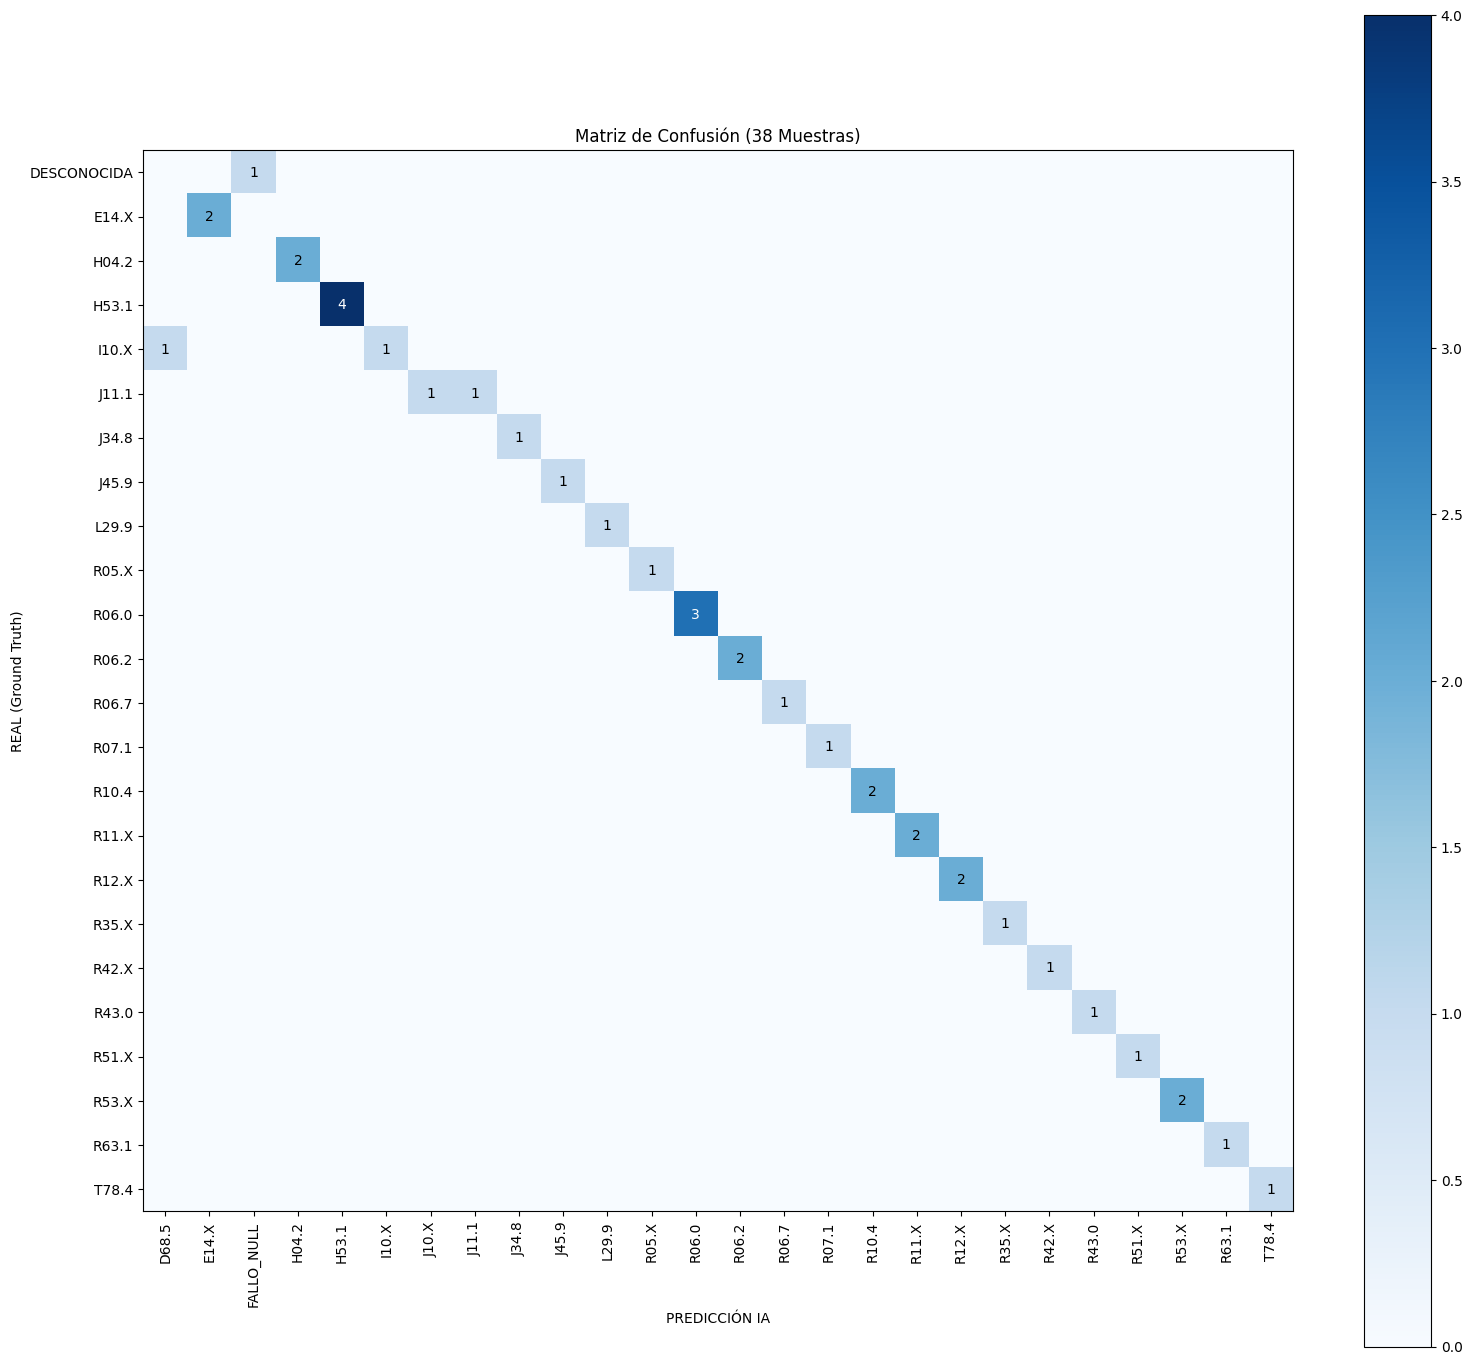

In [32]:

import pandas as pd
from pyspark.sql.types import StructType, StructField, StringType
import pyspark.sql.functions as F

print("--- INICIANDO CÁLCULO DE MÉTRICAS CON  ---")



data_golden = [
    # --- VISTA (Confirmado H53.1 y H04.2) ---
    ("sensibilidad a la luz", "H53.1"), 
    ("fotofobia", "H53.1"),
    ("molestia a la luz", "H53.1"), 
    ("visión borrosa", "H53.1"), 
    ("ojos llorosos", "H04.2"),             # Epífora (Confirmado)
    ("lagrimeo", "H04.2"),                  # Epífora

    # --- RESPIRATORIO (Confirmado R06.7, R06.0, R06.2) ---
    ("dificultad para respirar", "R06.0"), 
    ("falta de aire", "R06.0"),
    ("ahogo", "R06.0"), 
    ("sibilancias", "R06.2"), 
    ("le silba el pecho", "R06.2"),
    ("estornudos", "R06.7"),                # Estornudo (Confirmado)
    ("congestión nasal", "J34.8"),          # Otros transtornos... (Tu mapeo actual)
    ("tos seca", "R05.X"), 
    ("opresión en el pecho", "R07.1"),     

    # --- ESTÓMAGO (Confirmado R11.X, R12.X) ---
    ("acidez estomacal", "R12.X"), 
    ("ardor de estomago", "R12.X"),
    ("náuseas", "R11.X"),                   # Náusea y vómito (Confirmado)
    ("vómitos", "R11.X"),
    ("dolor abdominal", "R10.4"),           # Otros dolores abdominales...
    ("dolor de barriga", "R10.4"),

    # --- GENERALES (Confirmado R51.X, R42.X) ---
    ("dolor de cabeza", "R51.X"),           # Cefalea (Confirmado)
    ("mareos", "R42.X"),                    # Mareo y desvanecimiento (Confirmado)
    ("cansancio", "R53.X"), 
    ("fatiga", "R53.X"),
    
    # --- ESPECÍFICOS (Confirmado R63.1, R43.0) ---
    ("micción frecuente", "R35.X"), 
    ("sed excesiva", "R63.1"),              # Polidipsia (Confirmado)
    ("pérdida de olfato", "R43.0"),         # Anosmia (Confirmado)
    ("picazón", "L29.9"),                  
    
    # --- ENFERMEDADES ---
    ("diabetes", "E14.X"),                   
    ("azucar alta", "E14.X"),             
    ("hipertensión", "I10.X"),             
    ("presion alta", "I10.X"),            
    ("alergia", "T78.4"),                  
    ("asma", "J45.9"),                     
    ("gripe", "J11.1"), 
    ("influenza", "J11.1"), 
    
    # --- CONTROL ---
    ("texto_basura_sin_sentido", "DESCONOCIDA")
]

schema_golden = StructType([
    StructField("texto_original", StringType(), True),
    StructField("codigo_esperado", StringType(), True)
])

df_golden = spark.createDataFrame(data_golden, schema=schema_golden)

# 2. SIMULACIÓN DEL PIPELINE
df_test_clean = limpiar_texto(df_golden, "texto_original")
df_test_vec = model.transform(df_test_clean)

condicion_test = F.col("texto_limpio").rlike("desconocid")

df_test_pred = df_test_vec.withColumn("match", 
    F.when(condicion_test, 
         F.struct(F.lit("DESCONOCIDA").alias("COD"), F.lit("DESCONOCIDA").alias("DESC"))
    ).otherwise(match_udf(F.col("features")))
).select(
    "texto_original", 
    "codigo_esperado", 
    F.col("match.COD").alias("codigo_predicho"),
    F.col("match.DESC").alias("descripcion_predicha")
)

# 3. CÁLCULO MANUAL DE MÉTRICAS (Weighted Average)

df_pandas = df_test_pred.toPandas()
df_pandas["codigo_predicho"] = df_pandas["codigo_predicho"].fillna("FALLO_NULL")

# Normalizar
df_pandas["expected"] = df_pandas["codigo_esperado"].astype(str).str.strip()
df_pandas["predicted"] = df_pandas["codigo_predicho"].astype(str).str.strip()

# --- ALGORITMO DE CÁLCULO ---
clases_unicas = list(set(df_pandas["expected"].unique()) | set(df_pandas["predicted"].unique()))

weighted_precision = 0
weighted_recall = 0
weighted_f1 = 0
total_samples = len(df_pandas)

print("\n--- DETALLE POR CLASE (Cálculo Interno) ---")

for clase in clases_unicas:
    # True Positives (TP): Era X y predijo X
    tp = len(df_pandas[(df_pandas["expected"] == clase) & (df_pandas["predicted"] == clase)])
    
    # False Positives (FP): No era X, pero predijo X
    fp = len(df_pandas[(df_pandas["expected"] != clase) & (df_pandas["predicted"] == clase)])
    
    # False Negatives (FN): Era X, pero predijo otra cosa
    fn = len(df_pandas[(df_pandas["expected"] == clase) & (df_pandas["predicted"] != clase)])
    
    # Support (Cuántos casos reales había de esta clase)
    support = len(df_pandas[df_pandas["expected"] == clase])
    
    if support == 0: continue # Evitar división por cero si la clase solo apareció en predicción
    
    # Precisión Local = TP / (TP + FP)
    precision_local = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    # Recall Local = TP / (TP + FN)
    recall_local = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    # F1 Local
    f1_local = 2 * (precision_local * recall_local) / (precision_local + recall_local) if (precision_local + recall_local) > 0 else 0
    
    # Acumulamos ponderado por el peso de la clase (support)
    weighted_precision += precision_local * support
    weighted_recall += recall_local * support
    weighted_f1 += f1_local * support

# Promedios Ponderados Finales
final_accuracy = len(df_pandas[df_pandas["expected"] == df_pandas["predicted"]]) / total_samples
final_precision = weighted_precision / total_samples
final_recall = weighted_recall / total_samples
final_f1 = weighted_f1 / total_samples

# 4. REPORTE FINAL
print("\n" + "="*60)
print("📊 REPORTE DE MÉTRICAS (Weighted Average)")
print("="*60)
print(f"Accuracy (Exactitud):    {final_accuracy:.2%}")
print(f"Precision (Precisión):   {final_precision:.2%}")
print(f"Recall (Sensibilidad):   {final_recall:.2%}")
print(f"F1-Score (Balance):      {final_f1:.2%}")
print("="*60)

# 5. DETALLE DE ERRORES
df_errores = df_pandas[df_pandas["expected"] != df_pandas["predicted"]]


print("\n" + "="*60)
print("🟦 MATRIZ DE CONFUSIÓN (Real vs Predicción)")
print("="*60)
print("FILAS = Lo que DEBERÍA ser (Real)")
print("COLUMNAS = Lo que la IA PREDIJO")
print("-" * 60)

# Creamos la matriz usando Pandas Crosstab (Tabla Cruzada)
matriz_confusion = pd.crosstab(
    df_pandas["expected"], 
    df_pandas["predicted"], 
    rownames=['REAL (Ground Truth)'], 
    colnames=['PREDICCIÓN IA']
)

# Imprimimos la tabla
# Si la matriz es muy grande, Pandas la resumirá, pero para 40 casos se ve bien.
print(matriz_confusion)

import matplotlib.pyplot as plt

# 1. Configuración del Gráfico
print("\nGenerando gráfico de Matriz de Confusión...")
matriz_confusion = pd.crosstab(df_pandas["expected"], df_pandas["predicted"])

plt.figure(figsize=(16, 14)) # Un poco más grande para leer bien
plt.imshow(matriz_confusion, interpolation='nearest', cmap=plt.cm.Blues)
plt.title(f'Matriz de Confusión ({total_samples} Muestras)')
plt.colorbar()

# --- CORRECCIÓN AQUÍ: Calculamos ejes por separado ---
x_tick_marks = np.arange(len(matriz_confusion.columns))
y_tick_marks = np.arange(len(matriz_confusion.index))

plt.xticks(x_tick_marks, matriz_confusion.columns, rotation=90)
plt.yticks(y_tick_marks, matriz_confusion.index)
# -----------------------------------------------------

# Números en las celdas
for i in range(len(matriz_confusion.index)):
    for j in range(len(matriz_confusion.columns)):
        valor = matriz_confusion.iloc[i, j]
        if valor > 0:
            plt.text(j, i, str(valor),
                     horizontalalignment="center", verticalalignment="center",
                     color="white" if valor > (matriz_confusion.max().max() / 2) else "black")

plt.ylabel('REAL (Ground Truth)')
plt.xlabel('PREDICCIÓN IA')
plt.tight_layout()
plt.show()



In [ ]:
from pyspark.ml.feature import StringIndexer
from pyspark.ml import Pipeline

# 1. Necesitamos convertir las etiquetas de texto (CIE-10) a números
# Usamos StringIndexer. Importante: handleInvalid="keep" para que no falle si aparece una clase nueva.

# Indexamos la columna REAL
indexer_real = StringIndexer(inputCol="real", outputCol="labelIndex", handleInvalid="keep")

# Indexamos la columna PREDICHA
# (Nota: Idealmente deberían compartir el mismo indexer model si las clases son idénticas,
# pero para evaluación rápida esto funciona).
indexer_pred = StringIndexer(inputCol="prediccion", outputCol="predictionIndex", handleInvalid="keep")

# Transformamos el DataFrame
pipeline_indices = Pipeline(stages=[indexer_real, indexer_pred])
model_indices = pipeline_indices.fit(df_validacion)
df_evaluacion = model_indices.transform(df_validacion)

In [ ]:

from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# Definir las métricas que queremos calcular
metricas = ["accuracy", "weightedPrecision", "weightedRecall", "f1"]

print("--- REPORTE DE MÉTRICAS DISTRIBUIDAS (SPARK NATIVE) ---")

for metrica in metricas:
# Instanciamos el evaluador para cada métrica
evaluator = MulticlassClassificationEvaluator(
labelCol="labelIndex", # La columna con el valor real (numérico)
predictionCol="predictionIndex", # La columna con el valor predicho (numérico)
metricName=metrica # La métrica a calcular
)

# Calculamos
resultado = evaluator.evaluate(df_evaluacion)

print(f"{metrica}: {resultado:.4f}")

In [ ]:
from pyspark.mllib.evaluation import MulticlassMetrics

# 1. Necesitamos un RDD de tuplas (prediccion, real) tipo Double
# Usamos el df_evaluacion que ya tiene los índices numéricos
predictionAndLabels = df_evaluacion.select("predictionIndex", "labelIndex").rdd.map(lambda r: (float(r[0]), float(r[1])))

# 2. Instanciar métricas
metrics = MulticlassMetrics(predictionAndLabels)

# 3. Imprimir la Matriz
print("\n--- MATRIZ DE CONFUSIÓN (SPARK RDD) ---")
confusion_matrix = metrics.confusionMatrix().toArray()
print(confusion_matrix)
